C:\Users\91799\AppData\Local\Temp\ipykernel_13020\2088724322.py:9: DtypeWarning: Columns (295) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('V2A.CSV' , usecols=['V2AJ01a2','V2AJ01a1','PublicID'])


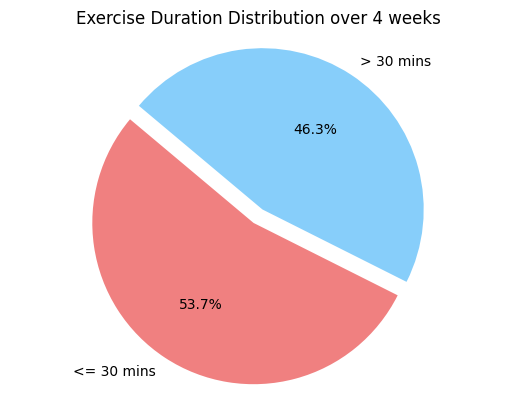

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
from pathlib import Path 

# Load data
df = pd.read_csv('V2A.CSV' , usecols=['V2AJ01a2','V2AJ01a1','PublicID'])
# df2 = pd.read_csv('V3A.CSV')

# Merge data
# df = pd.merge(df1, df2, on="PublicID")
# Convert the 'V2AJ01a2' column to numeric format
df['V2AJ01a2'] = pd.to_numeric(df['V2AJ01a2'], errors='coerce')

# Drop rows with missing or non-numeric values in the 'V2AJ01a2' column
df = df.dropna(subset=['V2AJ01a2'])

# Filter the DataFrame to include only rows where exercise duration is more than 30 minutes
filtered_df = df[df['V2AJ01a2'] > 30]

# Count the number of times individuals exercised for more than 30 minutes
num_exercises_gt_30mins = filtered_df['V2AJ01a1'].count()

# Count the number of times individuals exercised for 30 minutes or less
num_exercises_lte_30mins = df['V2AJ01a1'].count() - num_exercises_gt_30mins

# Create a pie chart to visualize the distribution
labels = ['<= 30 mins', '> 30 mins']
sizes = [num_exercises_lte_30mins, num_exercises_gt_30mins]
colors = ['lightcoral', 'lightskyblue']
explode = (0, 0.1)

plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.axis('equal')
plt.title('Exercise Duration Distribution over 4 weeks')

# Show the pie chart
plt.show()


df['V2AJ01a1'] = pd.to_numeric(df['V2AJ01a1'], errors='coerce')

# Drop rows with missing or non-numeric values in the 'V2AJ01a1' column
df = df.dropna(subset=['V2AJ01a1'])

# Calculate the total number of days individuals were physically active
active_days = df['V2AJ01a1']

# Count the occurrences of each number of active days
df['active_days'] = active_days.value_counts()

# Create a bar plot to visualize the distribution
# active_days_counts.plot(kind='bar')

# # Add labels and title to the plot
# plt.xlabel('Number of Active Days')
# plt.ylabel('Count')
# plt.title('Number of Days Individuals were Physically Active')

# # Show the plot
# plt.show()




In [2]:
filtered_df

,PublicID,V2AJ01a1,V2AJ01a2
3,00015J,3,45.0
5,00017F,3,60.0
6,00018D,3,60.0
13,00027C,7,120.0
14,00029V,6,120.0
...,...,...,...
8724,17339L,3.0,40.0
8727,17343U,1.0,75.0
8729,17349I,1.0,60.0
8730,17350A,5.0,120.0


In [3]:
num_exercises_gt_30mins

2945

In [4]:
df = df.drop(['active_days'], axis=1)

In [5]:
df = df.dropna()

In [20]:
df.describe()

,V2AJ01a1,V2AJ01a2,V4AH01,MH_outcome
count,3287.000000,3287.000000,3287.000000,3287.000000
mean,3.462428,44.179191,1.603590,0.378156
std,2.020822,42.228689,0.866373,0.485001
min,0.000000,1.000000,1.000000,0.000000
25%,2.000000,30.000000,1.000000,0.000000
50%,3.000000,30.000000,1.000000,0.000000
75%,5.000000,60.000000,3.000000,1.000000
max,21.000000,720.000000,3.000000,1.000000


In [10]:
df_out = pd.read_csv('outcome.csv',usecols=['MH_outcome','PublicID'])
df = pd.merge(df, df_out, on='PublicID', how='inner')


In [22]:
# df = df.dropna()

one_hot_encoded = pd.get_dummies(df['V2AJ01a1'], prefix='V2AJ01a1')
df = df.join(one_hot_encoded)

df

,PublicID,V2AJ01a1,V2AJ01a2,V4AH01,MH_outcome,V2AJ01a1_0.0,V2AJ01a1_1.0,V2AJ01a1_2.0,V2AJ01a1_3.0,V2AJ01a1_4.0,V2AJ01a1_5.0,V2AJ01a1_6.0,V2AJ01a1_7.0,V2AJ01a1_8.0,V2AJ01a1_10.0,V2AJ01a1_12.0,V2AJ01a1_14.0,V2AJ01a1_21.0
0,00007I,7.0,20.0,2.0,1,False,False,False,False,False,False,False,True,False,False,False,False,False
1,00008G,3.0,30.0,3.0,0,False,False,False,True,False,False,False,False,False,False,False,False,False
2,00017F,3.0,60.0,1.0,1,False,False,False,True,False,False,False,False,False,False,False,False,False
3,00027C,7.0,120.0,2.0,0,False,False,False,False,False,False,False,True,False,False,False,False,False
4,00030N,1.0,45.0,1.0,0,False,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3282,17335T,7.0,35.0,1.0,0,False,False,False,False,False,False,False,True,False,False,False,False,False
3283,17339L,3.0,40.0,1.0,0,False,False,False,True,False,False,False,False,False,False,False,False,False
3284,17343U,1.0,75.0,1.0,1,False,True,False,False,False,False,False,False,False,False,False,False,False
3285,17345Q,2.0,30.0,1.0,0,False,False,True,False,False,False,False,False,False,False,False,False,False


In [23]:
scaler = MinMaxScaler()
df['V2AJ01a2'] = scaler.fit_transform(df[['V2AJ01a2']])


In [31]:
df_pa = df
%store df_pa

Stored 'df_pa' (DataFrame)


In [29]:
X = df.drop(['PublicID','V2AJ01a1','V4AH01','MH_outcome','V2AJ01a1_0.0','V2AJ01a1_21.0'],axis=1)
y = df['MH_outcome']


In [28]:
df['V2AJ01a1'].value_counts()

V2AJ01a1
3.0     767
2.0     707
1.0     519
7.0     432
4.0     386
5.0     366
6.0      85
10.0     10
14.0      7
0.0       5
21.0      1
12.0      1
8.0       1
Name: count, dtype: int64

0       1
1       0
2       1
3       0
4       0
       ..
3282    0
3283    0
3284    1
3285    0
3286    1
Name: MH_outcome, Length: 3287, dtype: int64

In [14]:
# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()

# X_scaled = scaler.fit_transform(X)

# X = pd.DataFrame(X_scaled, columns=X.columns)



In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE


X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

model = LogisticRegression(solver='liblinear')

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef}")


Model Coefficients:
V2AJ01a2: -0.3732837165588208
V2AJ01a1_1.0: 0.1698345857744314
V2AJ01a1_2.0: -0.03706518388342832
V2AJ01a1_3.0: -0.028563144988855853
V2AJ01a1_4.0: 0.10444599643680955
V2AJ01a1_5.0: 0.436525945709272
V2AJ01a1_6.0: 0.28245134537257266
V2AJ01a1_7.0: 0.24213260319257923
V2AJ01a1_8.0: 0.42116637549243907
V2AJ01a1_10.0: 0.656080359556839
V2AJ01a1_12.0: -0.37917653173361077
V2AJ01a1_14.0: -0.6242273340801145


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Compute evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

# Print the evaluation metrics
print("Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")

Evaluation Metrics:
Accuracy: 0.4924
Precision: 0.5104
Recall: 0.4924
F1-score: 0.4987
ROC AUC: 0.4730


In [7]:
pip install pyarrow

   ---------------------------------------- 0.0/24.9 MB ? eta -:--:--
   -- ------------------------------------- 1.4/24.9 MB 42.9 MB/s eta 0:00:01
   ------- -------------------------------- 4.6/24.9 MB 48.9 MB/s eta 0:00:01
   ---------- ----------------------------- 6.8/24.9 MB 47.9 MB/s eta 0:00:01
   ------------ --------------------------- 8.0/24.9 MB 42.5 MB/s eta 0:00:01
   ------------- -------------------------- 8.5/24.9 MB 36.1 MB/s eta 0:00:01
   -------------- ------------------------- 9.1/24.9 MB 30.5 MB/s eta 0:00:01
   --------------- ------------------------ 9.6/24.9 MB 26.5 MB/s eta 0:00:01
   --------------- ------------------------ 9.9/24.9 MB 25.2 MB/s eta 0:00:01
   ---------------- ----------------------- 10.1/24.9 MB 23.1 MB/s eta 0:00:01
   ---------------- ----------------------- 10.4/24.9 MB 21.1 MB/s eta 0:00:01
   ---------------- ----------------------- 10.6/24.9 MB 19.8 MB/s eta 0:00:01
   ----------------- ---------------------- 10.7/24.9 MB 17.7 MB/s et